In [21]:
import networkx as nx
from Clustering_Functions import *
from itertools import permutations
import numpy as np
from networkx.algorithms import community
import pandas as pd
import seaborn as sns
import glob

In [ ]:
filename_list = glob.glob("scot-elex/**/*.csv")
results2 = pd.DataFrame(columns=['filename', 'num_cands', 'clustering', 'k', 'mod'])
count = 1

for filename in filename_list:
    num_cands, election, cand_list, ward = csv_parse(filename)
    party_names = party_abrevs(cand_list)
    C, modularity = Modularity_cluster(election, num_cands=num_cands)
    C_dict = {n:C[n] for n in range(len(C))}
    k = len(C)
    print(count, filename, k, modularity)
    count +=1
    row_num = results2.shape[0]
    results2.loc[row_num] = [filename, num_cands,C_dict, k, modularity]

In [19]:
results2.to_pickle('modularity_clusterings.pkl')

<Axes: xlabel='k', ylabel='Count'>

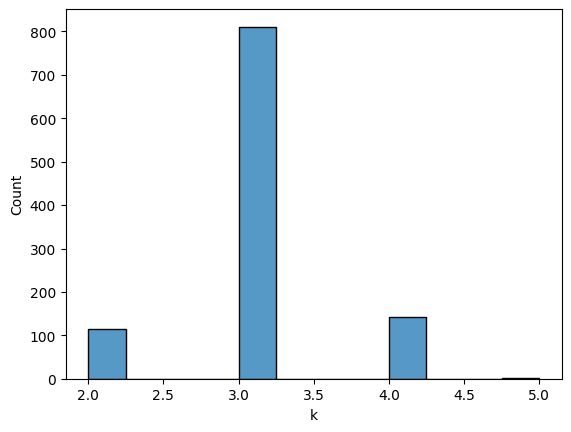

In [25]:
sns.histplot(results2, x='k')

<Axes: xlabel='mod', ylabel='Count'>

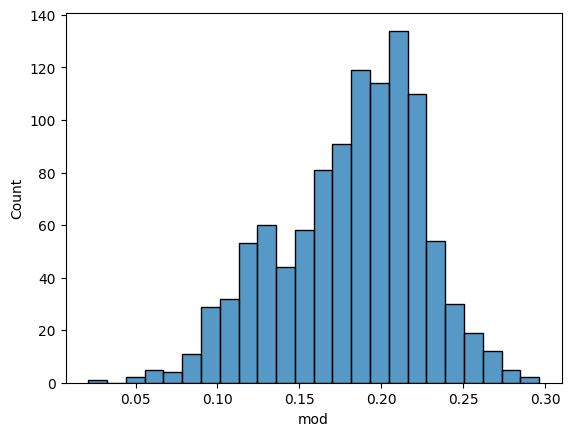

In [27]:
sns.histplot(results2,x='mod')

<Axes: xlabel='mod', ylabel='num_cands'>

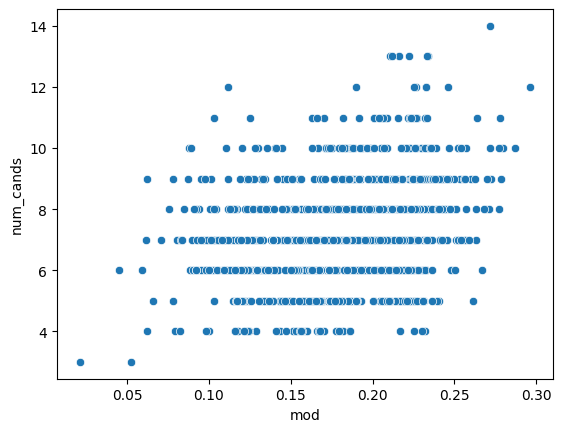

In [28]:
sns.scatterplot(results2,x='mod',y='num_cands')

In [52]:
results2['k'].unique()

array([3, 4, 2, 5], dtype=int64)

In [55]:
for k in range(1,6):
    print(k,len(results2[results2['k']==k])/len(results2)) 

1 0.0
2 0.10654205607476636
3 0.7579439252336448
4 0.1336448598130841
5 0.001869158878504673


In [56]:
len(results2)

1070

In [57]:
results2.columns

Index(['filename', 'num_cands', 'clustering', 'k', 'mod'], dtype='object')

In [59]:
results = results2
len(results)

1070

In [ ]:
ls = []
count = 1
for index in results.index:
    filename = results['filename'][index]
    C_m = results['clustering'][index] # is a dictionary
    C_mod = [C_m[n] for n in range(len(C_m))] #is converted into a list
    k = results['k'][index]
    num_cands, election, cand_list, ward = csv_parse(filename)
    C_loyd = kmeans(election, k=k)
    dif = Clustering_closeness(election, C_mod, C_loyd)
    ls.append(dif)
    print(count, filename)
    count +=1

results['dif']=ls

<Axes: xlabel='dif', ylabel='Count'>

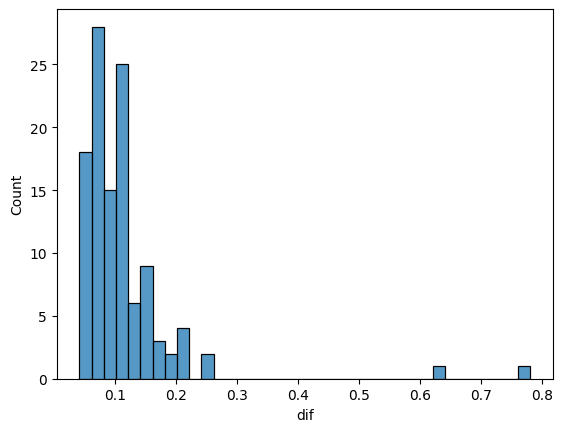

In [67]:
sns.histplot(results[results['k']==2],x='dif')

<Axes: xlabel='dif'>

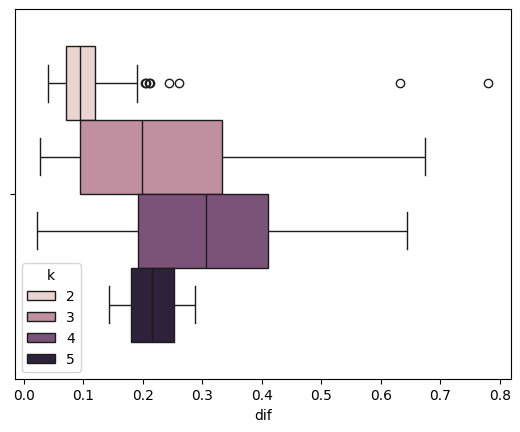

In [76]:
sns.boxplot(results,x='dif', hue = 'k')

In [72]:
ls = []
for index in results.index:
    filename = results['filename'][index]
    C_m = results['clustering'][index] # is a dictionary
    C_mod = [C_m[n] for n in range(len(C_m))] #is converted into a list
    lengths = [ sum(C.values()) for C in C_mod ]
    x = min(lengths)/sum(lengths)
    ls.append(x)

results['smallest']=ls    

<Axes: xlabel='smallest'>

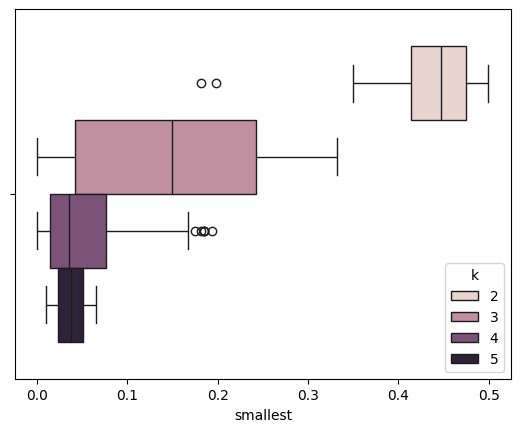

In [75]:
sns.boxplot(results,x='smallest', hue='k')

In [80]:
test = results[results['filename'].str.contains('edinburgh_2017_ward2') ]

In [81]:
test

,filename,num_cands,clustering,k,mod,dif,smallest
549,scot-elex\7_cands\edinburgh_2017_ward2.csv,7,"{0: {(4, 5, 3, 2, 1, 6): 2, (3, 4, 7, 5, 2, 1)...",3,0.227364,0.081396,0.23924


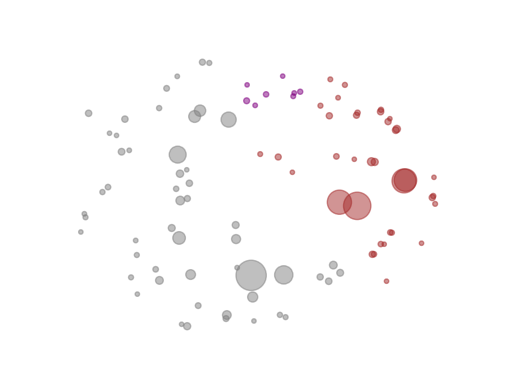

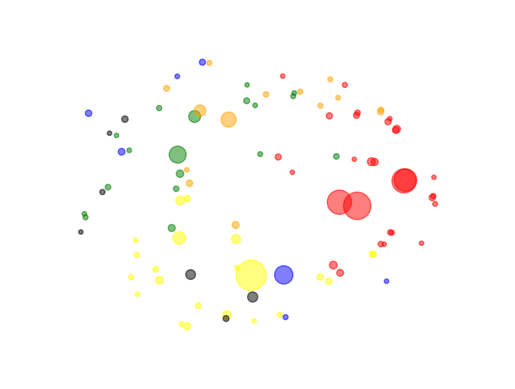

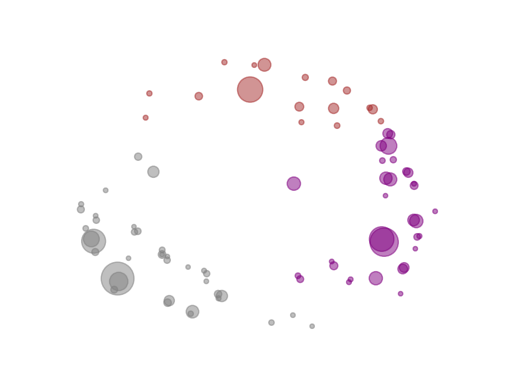

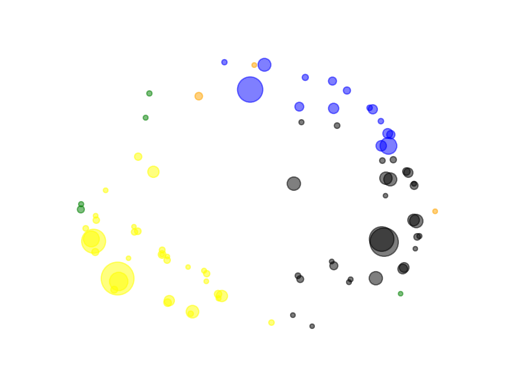

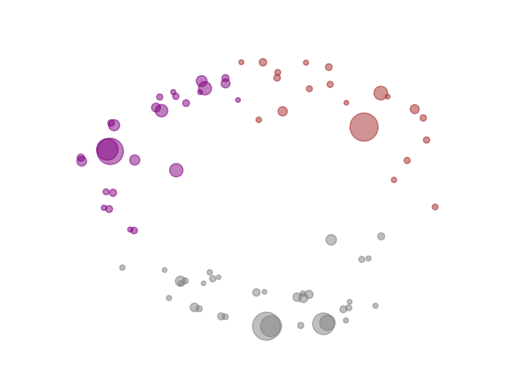

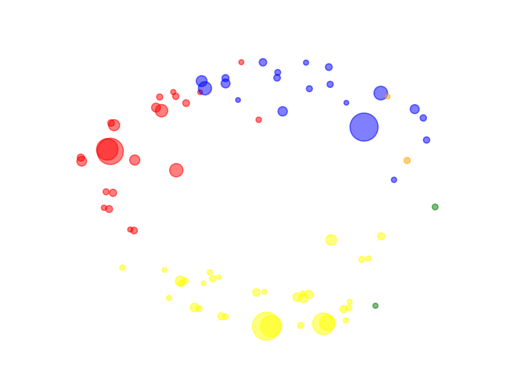

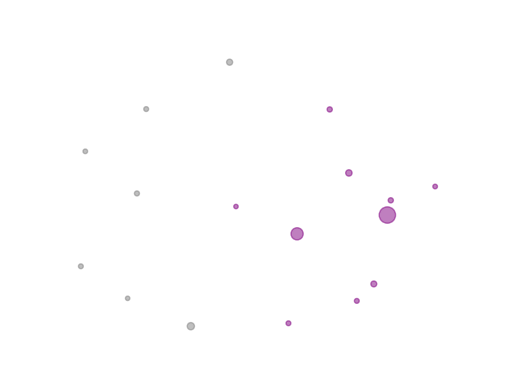

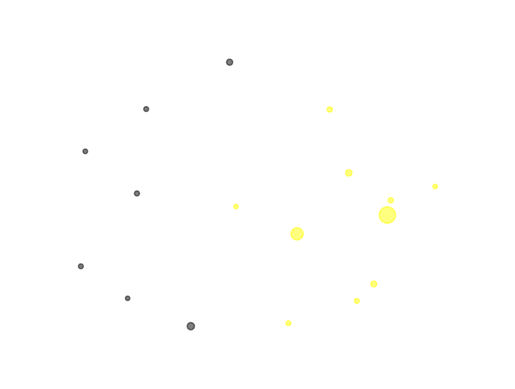

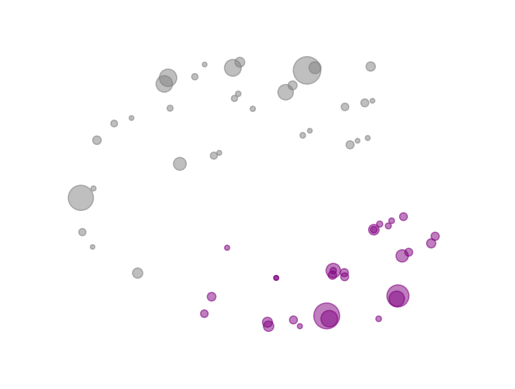

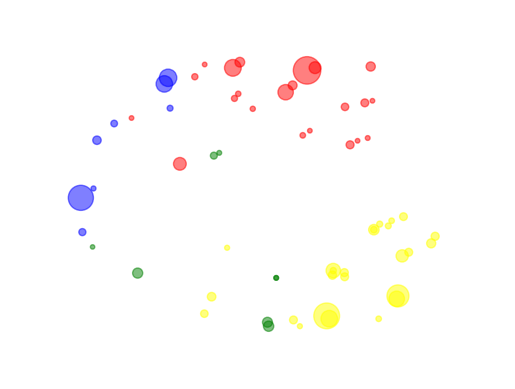

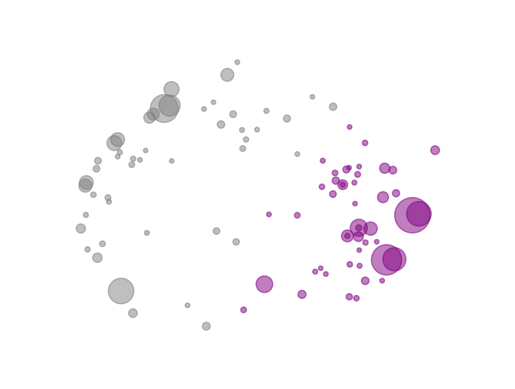

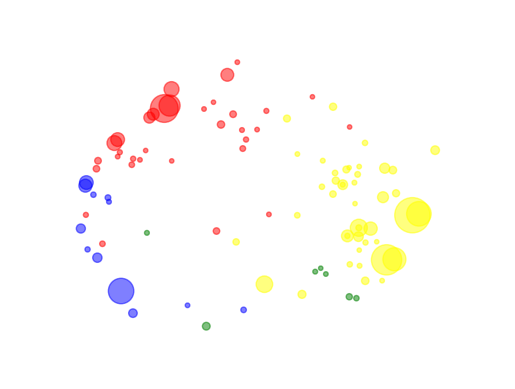

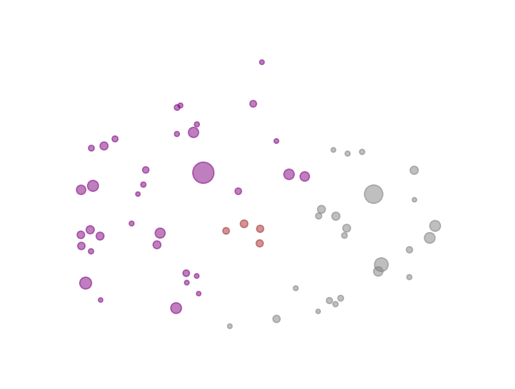

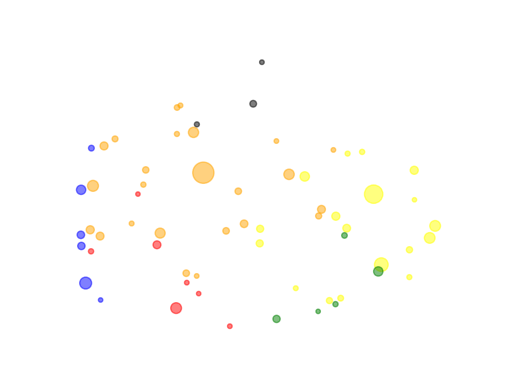

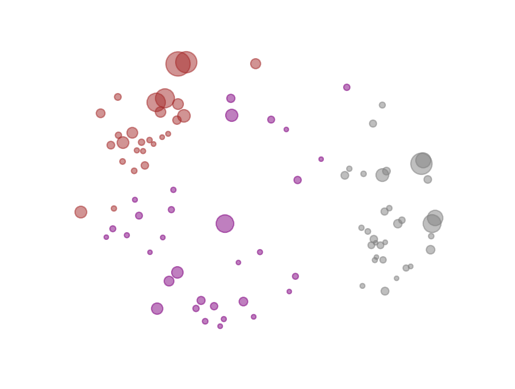

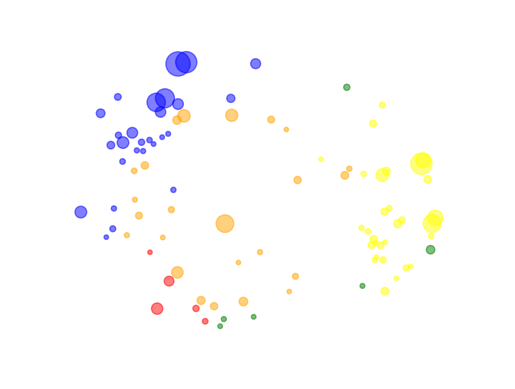

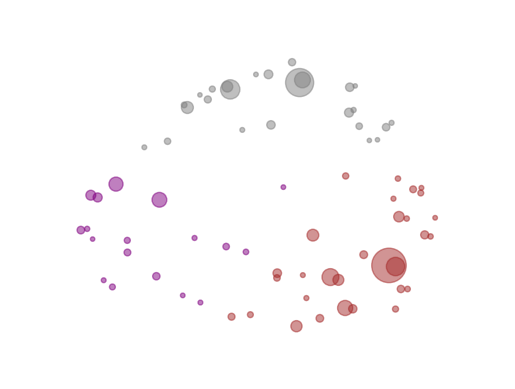

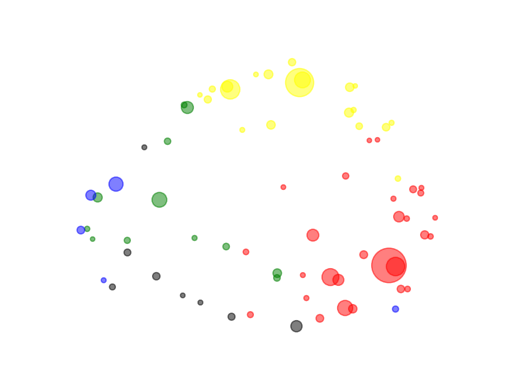

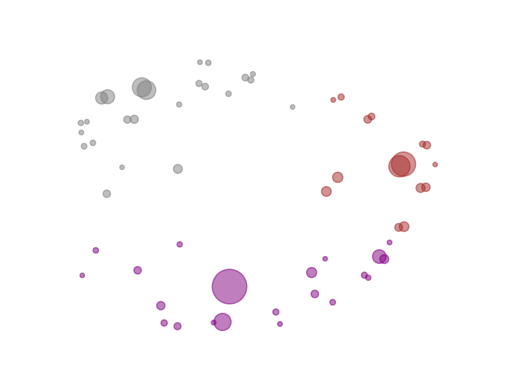

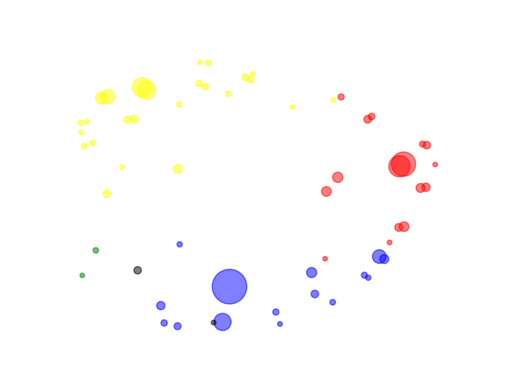

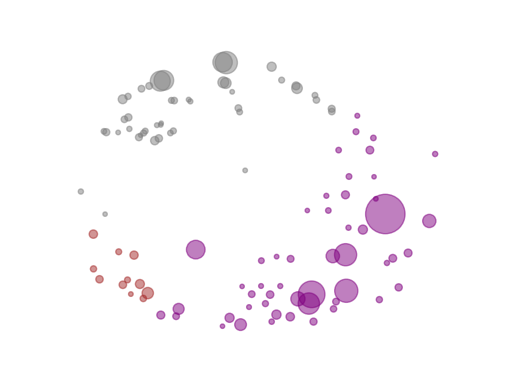

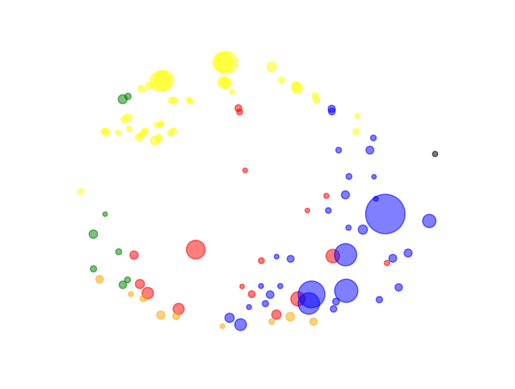

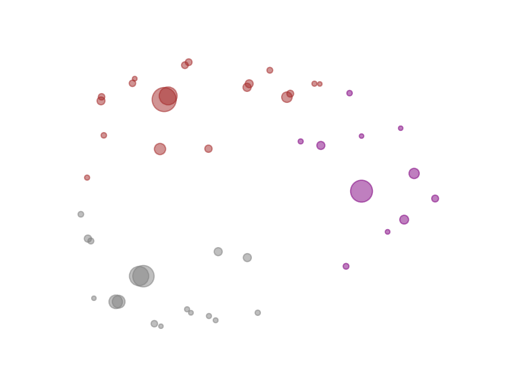

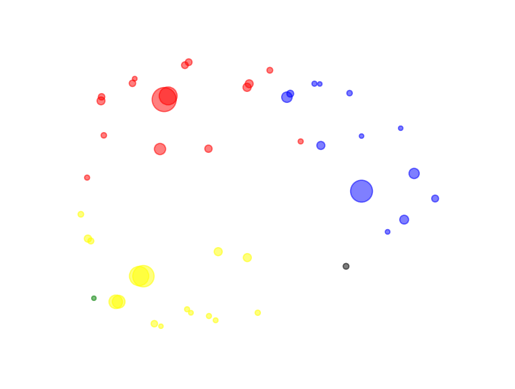

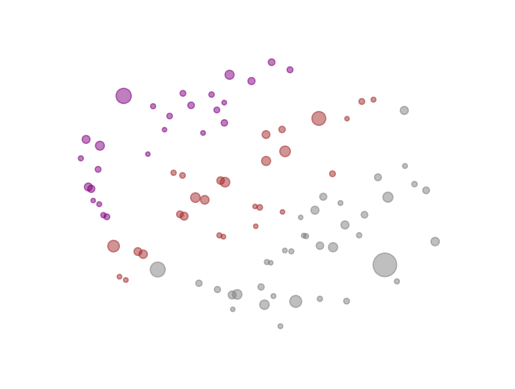

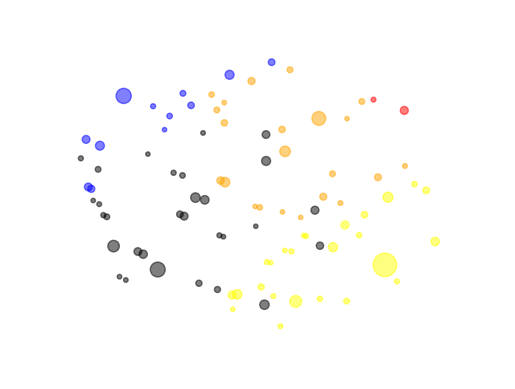

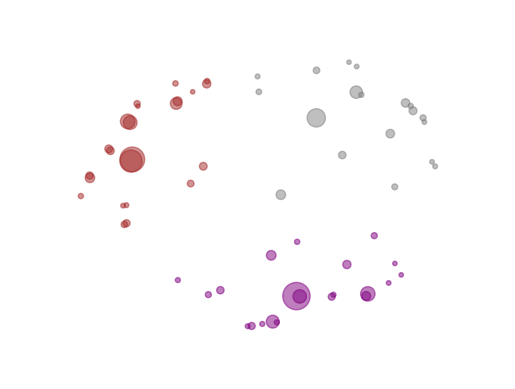

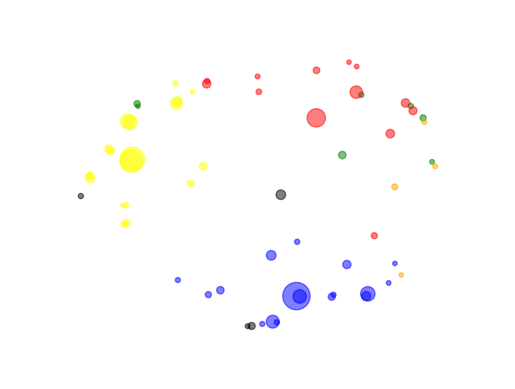

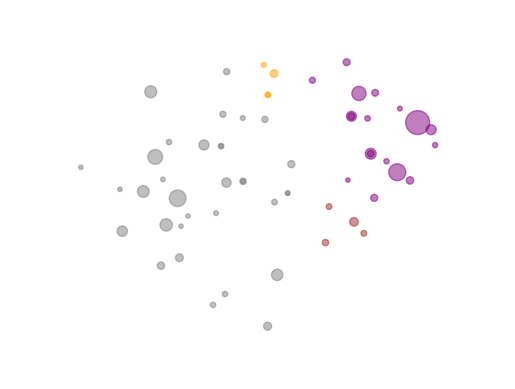

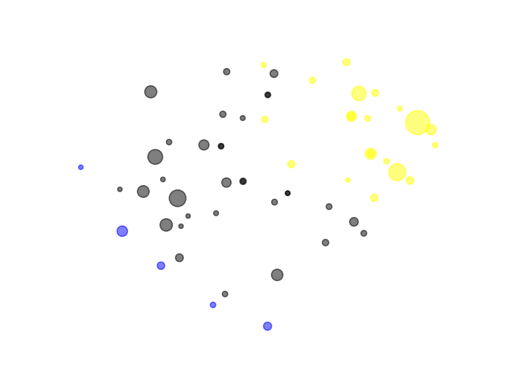

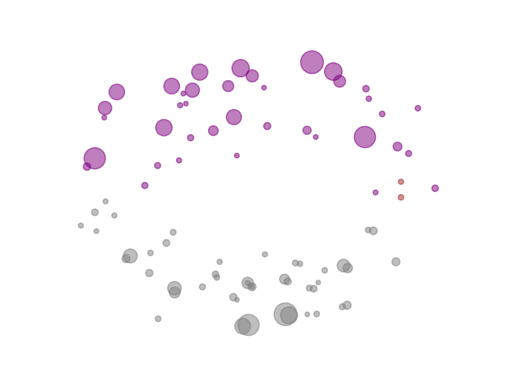

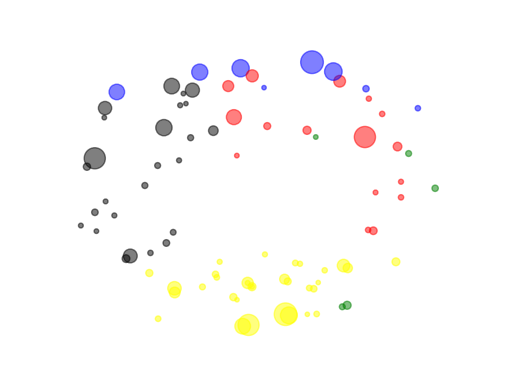

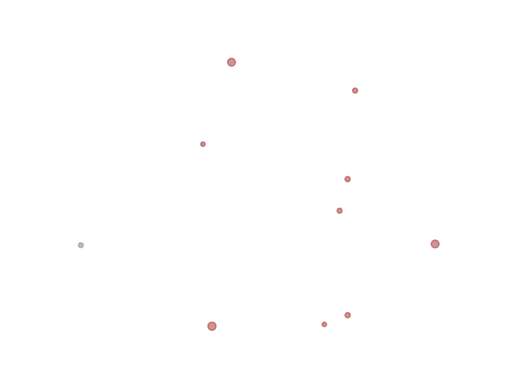

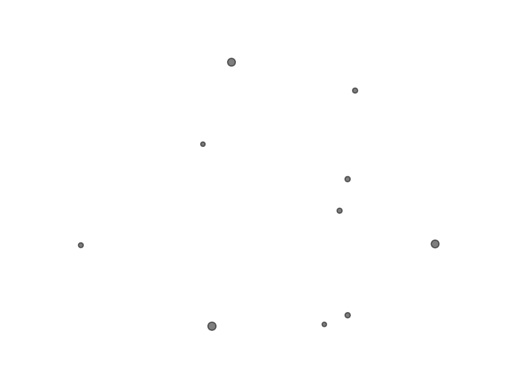

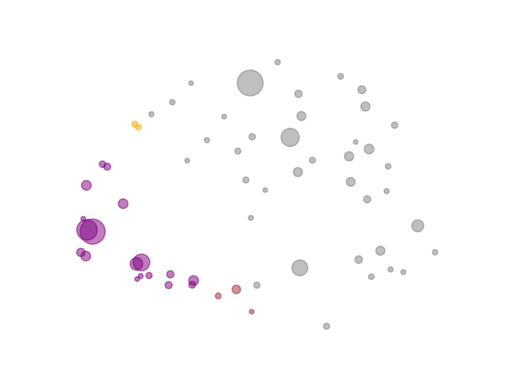

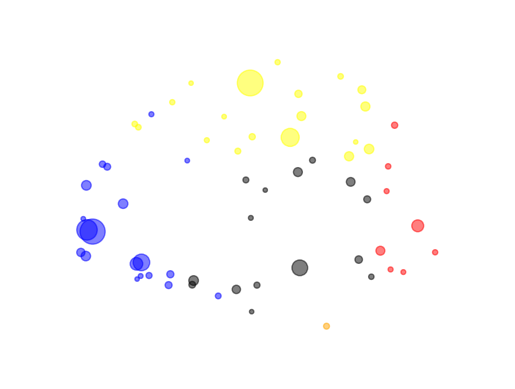

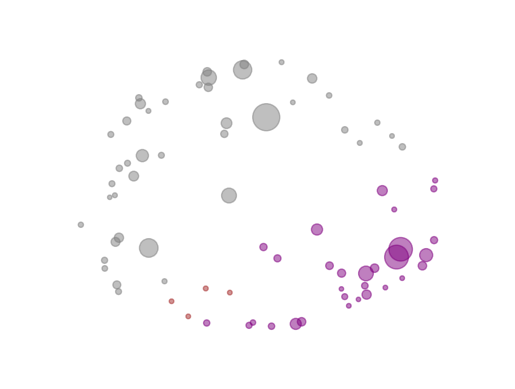

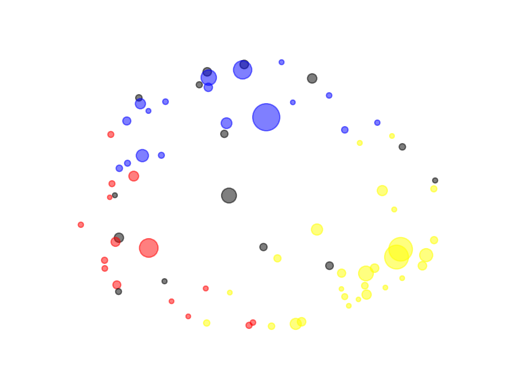

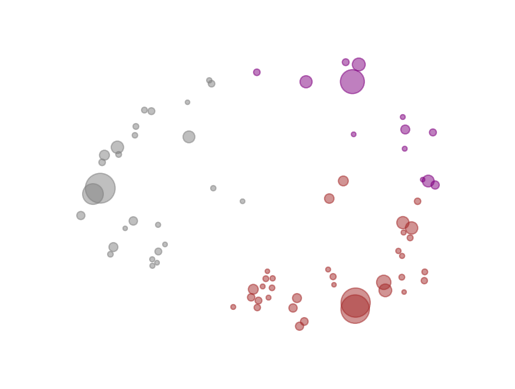

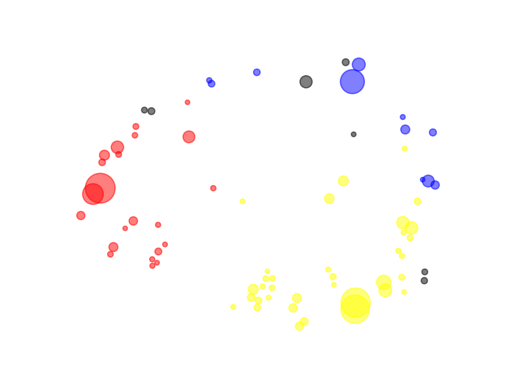

In [85]:
for _ in range(20):
    filename=np.random.choice(filename_list)
    num_cands, election, cand_list, ward = csv_parse(filename)
    party_names = party_abrevs(cand_list)
    C, modularity = Modularity_cluster(election, num_cands=num_cands)
    projections = Ballot_MDS_plot(election, C, return_projections=True)
    Ballot_MDS_plot(election, party_names=party_names, projections=projections)
    